In [8]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('../src'))
from src.models.perceptron import Perceptron

# 1. Generování dat
np.random.seed(42)
X = np.random.uniform(-10, 10, (100, 2))

# Cílová funkce: y = 3x + 2
y_true = np.array([1 if p[1] > (3 * p[0] + 2) else -1 for p in X])

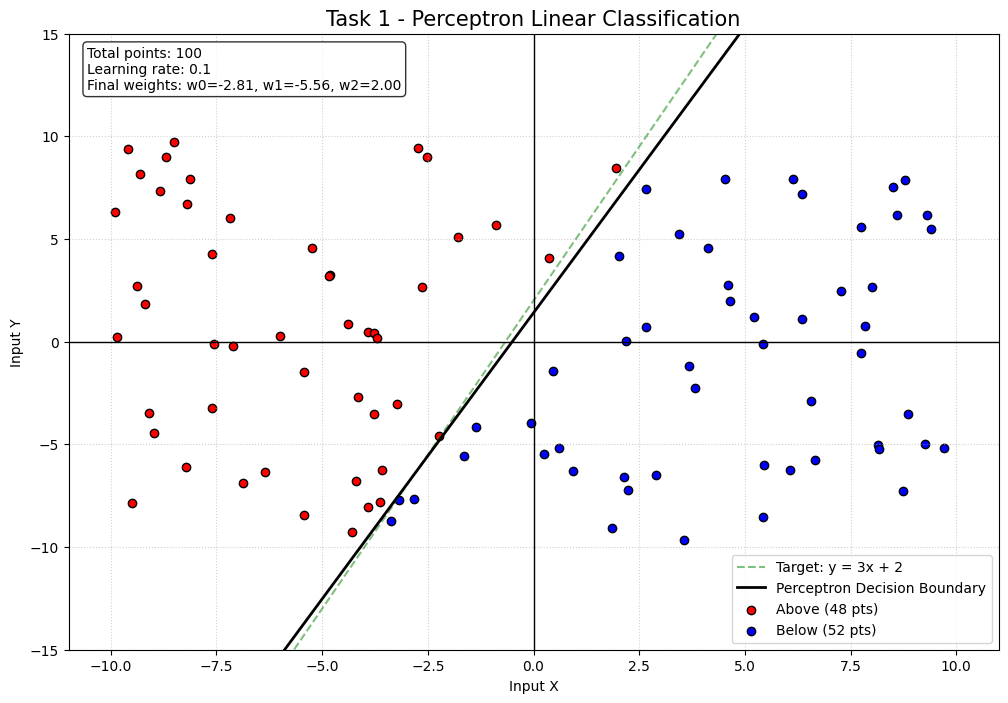

In [9]:
# 1. Příprava 
output_dir = "../results/01_perceptron"
os.makedirs(output_dir, exist_ok=True)

# 2. Trénink modelu 
model = Perceptron(input_size=2 , lr=0.1, epochs=100)
model.train(X, y_true)

# 3. Vizualizace 
plt.figure(figsize=(12, 8))

# Vykreslení dělící čáry 
x_vals = np.array([-10, 10])
plt.plot(x_vals, 3 * x_vals + 2, 'g--', label='Target: y = 3x + 2', alpha=0.5)

# Vykreslení čáry, kterou reálně našel Perceptron
# Rovnice: w1*x + w2*y + w0 = 0  =>  y = -(w1*x + w0) / w2
w0, w1, w2 = model.weights
p_y_vals = -(w1 * x_vals + w0) / w2
plt.plot(x_vals, p_y_vals, 'k-', label='Perceptron Decision Boundary', linewidth=2)

# Vykreslení bodů s rozlišením
red_points = X[y_true == 1]
blue_points = X[y_true == -1]

plt.scatter(red_points[:, 0], red_points[:, 1], c='red', edgecolors='k', label=f'Above ({len(red_points)} pts)')
plt.scatter(blue_points[:, 0], blue_points[:, 1], c='blue', edgecolors='k', label=f'Below ({len(blue_points)} pts)')

# Dekorace a info box
info_text = (f"Total points: {len(X)}\n"
             f"Learning rate: {model.lr}\n"
             f"Final weights: w0={w0:.2f}, w1={w1:.2f}, w2={w2:.2f}")

plt.gca().text(0.02, 0.98, info_text, transform=plt.gca().transAxes, 
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlim(-11, 11)
plt.ylim(-15, 15) 
plt.title("Task 1 - Perceptron Linear Classification", fontsize=15)
plt.xlabel("Input X")
plt.ylabel("Input Y")
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

# 4. ULOŽENÍ
file_path = os.path.join(output_dir, "perceptron_result.png")
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()